# Project Milestone Two

**Data Preparation and Model Exploration**

**Note: No late assignments accepted, we need the time to grade them!**

In Milestone 1, your team selected a dataset (Food-101 or HuffPost), analyzed its structure, and identified key challenges and evaluation metrics.
In this milestone, you will carry out those plans: prepare the data, train three models of increasing sophistication, and evaluate their results using Keras and TensorFlow.
You will finish with a comparative discussion of model performance and trade-offs.


### Submission Guidelines

* Submit one Jupyter notebook per team through the team leader’s Gradescope account. **Include all team members names at the top of the notebook.**
* Include all code, plots, and answers inline below.
* Ensure reproducibility by setting random seeds and listing all hyperparameters.
* Document any AI tools used, as required by the CDS policy.


## Problem 1 – Data Preparation and Splits (20 pts)

### Goals

Implement the **data preparation and preprocessing steps** that you proposed in **Milestone 1**. You’ll clean, normalize, and split your data so that it’s ready for modeling and reproducible fine-tuning.

### Steps to Follow

1. **Load your chosen dataset**

   * Use `datasets.load_dataset()` from **Hugging Face** to load **Food-101** or **HuffPost**.
   * Display basic information (e.g., number of samples, feature names, example entries).

2. **Apply cleaning and normalization**

   * **Images:**

     * Ensure all images are in RGB format.
     * Resize or crop to a consistent shape (e.g., `224 × 224`).
     * Drop or fix any corrupted files.
   * **Text:**

     * Concatenate headline + summary (for HuffPost).
     * Strip whitespace, convert to lowercase if appropriate, and remove empty samples.
     * Optionally remove duplicates or extremely short entries.

3. **Standardize or tokenize the inputs**

   * **Images:**

     * Normalize pixel values (e.g., divide by 255.0).
     * Define a minimal augmentation pipeline (e.g., random flip, crop, or rotation).
   * **Text:**

     * Create a tokenizer or `TextVectorization` layer.
     * Set a target `max_length` based on your analysis from Milestone 1 (e.g., 95th percentile).
     * Apply padding/truncation and build tensors for input + labels.

4. **Handle dataset-specific challenges**

   * If you identified **class imbalance**, compute label counts and, if needed, create a dictionary of `class_weights`.
   * If you noted **length or size variance**, verify that your truncation or resizing works as intended.
   * If you planned **noise filtering**, include the cleaning step and briefly explain your criteria (e.g., remove items with missing text or unreadable images).

5. **Create reproducible splits**

   * Split your cleaned dataset into **train**, **validation**, and **test** subsets (e.g., 80 / 10 / 10).
   * Use a fixed random seed for reproducibility (`random_seed = 42`).
   * Use **stratified splits**  (e.g., with `train_test_split` and `stratify = labels`).
   * Display the size of each subset.

6. **Document your pipeline**

   * Summarize your preprocessing steps clearly in Markdown or code comments.
   * Save or display a few representative examples after preprocessing to confirm the transformations are correct.




In [2]:
# Your code here; add as many cells as you need but make it clear what the structure is.
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
VOCAB_SIZE = 20000
BATCH_SIZE = 32

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Random seed set to:", SEED)

URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"

huff_all = load_dataset("json", data_files=URL, split="train")
df = pd.DataFrame(huff_all)

print("\nDataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nSample record:")
print(df.iloc[0])

df = df[["headline", "short_description", "category"]].copy()

df["headline"] = df["headline"].fillna("").astype(str).str.strip()
df["short_description"] = df["short_description"].fillna("").astype(str).str.strip()
df["category"] = df["category"].fillna("").astype(str).str.strip()

df["text"] = df["headline"] + " [SEP] " + df["short_description"]
df["text"] = df["text"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()

df = df[df["text"].str.len() > 10]
df = df[df["category"] != ""]
df = df.drop_duplicates(subset=["text", "category"]).reset_index(drop=True)

print("\nShape after cleaning:", df.shape)

label_counts = df["category"].value_counts()

print("\nNumber of classes:", df["category"].nunique())
print("\nTop 10 classes by count:")
print(label_counts.head(10))

imbalance_ratio = label_counts.max() / label_counts.median()
print("\nImbalance ratio (max / median):", round(imbalance_ratio, 2))

df["word_count"] = df["text"].apply(lambda x: len(x.split()))

print("\nWord count summary:")
print(df["word_count"].describe())

MAX_LENGTH = int(df["word_count"].quantile(0.95))
print("\nChosen max length based on 95th percentile:", MAX_LENGTH)

label_names = sorted(df["category"].unique())
label_to_id = {label: idx for idx, label in enumerate(label_names)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

df["label"] = df["category"].map(label_to_id)

print("\nTotal labels:", len(label_names))
print("Sample label mapping:", dict(list(label_to_id.items())[:10]))

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

train_texts = set(train_df["text"])
val_texts = set(val_df["text"])
test_texts = set(test_df["text"])

print("\nLeakage check:")
print("Train-Val overlap:", len(train_texts.intersection(val_texts)))
print("Train-Test overlap:", len(train_texts.intersection(test_texts)))
print("Val-Test overlap:", len(val_texts.intersection(test_texts)))

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_LENGTH
)

vectorizer.adapt(train_df["text"].values)

print("\nVocabulary size learned:", len(vectorizer.get_vocabulary()))

def make_dataset(dataframe, shuffle=False):
    texts = dataframe["text"].values
    labels = dataframe["label"].values

    ds = tf.data.Dataset.from_tensor_slices((texts, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.map(lambda x, y: (vectorizer(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

print("\nTensorFlow datasets created successfully.")

classes = np.array(sorted(train_df["label"].unique()))

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = {int(cls): float(weight) for cls, weight in zip(classes, class_weights_array)}

print("\nSample class weights:")
print(dict(list(class_weights.items())[:10]))

for batch_x, batch_y in train_ds.take(1):
    print("\nSample processed batch:")
    print("Input shape:", batch_x.shape)
    print("Label shape:", batch_y.shape)
    print("First sample token ids:", batch_x[0][:30].numpy())
    print("First sample label id:", batch_y[0].numpy())
    print("First sample label name:", id_to_label[int(batch_y[0].numpy())])

print("\nSample cleaned text examples:")
for i in range(3):
    print(f"\nExample {i+1}:")
    print("Category:", train_df.iloc[i]["category"])
    print("Text:", train_df.iloc[i]["text"][:300])


TensorFlow version: 2.19.0
Random seed set to: 42


News_Category_Dataset_v2.json:   0%|          | 0.00/83.9M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]


Dataset shape: (200853, 6)
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']

Sample record:
category                                                         CRIME
headline             There Were 2 Mass Shootings In Texas Last Week...
authors                                                Melissa Jeltsen
link                 https://www.huffingtonpost.com/entry/texas-ama...
short_description    She left her husband. He killed their children...
date                                               2018-05-26 00:00:00
Name: 0, dtype: object

Shape after cleaning: (200365, 4)

Number of classes: 41

Top 10 classes by count:
category
POLITICS          32721
WELLNESS          17822
ENTERTAINMENT     16054
TRAVEL             9882
STYLE & BEAUTY     9515
PARENTING          8649
HEALTHY LIVING     6688
QUEER VOICES       6310
FOOD & DRINK       6226
BUSINESS           5934
Name: count, dtype: int64

Imbalance ratio (max / median): 9.62

Word count summary:
count  

### Graded Questions (5 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **Data Loading and Cleaning:**
   Describe how you loaded your dataset and the key cleaning steps you implemented (e.g., handling missing data, normalizing formats, or removing duplicates).



1.1. **Your answer here:**
The HuffPost dataset was loaded from a JSON source using Hugging Face’s dataset loader and converted into a pandas DataFrame for easier analysis. The key fields used for this task were headline, short_description, and category.

During cleaning, missing values were handled by replacing nulls with empty strings and removing rows with empty categories. The headline and short description were combined into a single text field using a separator ([SEP]) to retain structure. The text was normalized by converting it to lowercase, removing extra whitespace, and filtering out very short or low-information entries. Duplicate rows were also removed to improve overall data quality.



2. **Preprocessing and Standardization:**
   Summarize your preprocessing pipeline. Include any normalization, tokenization, resizing, or augmentation steps, and explain why each was necessary for your dataset.
  

1.2. **Your answer here:**
The text data was transformed into a format suitable for modeling through tokenization and standardization. Based on an analysis of text length distribution, a maximum sequence length was selected using the 95th percentile to balance efficiency and information retention. A TextVectorization layer was used to tokenize the input. Padding and truncation were applied to ensure all inputs have a consistent length.



3. **Train/Validation/Test Splits:**
   Explain how you divided your data into subsets, including the split ratios, random seed, and any stratification or leakage checks you used to verify correctness.


1.3. **Your answer here:**
The dataset was split into training, validation, and test sets using an 80/10/10 ratio. A fixed random seed (seed = 42) was used to ensure reproducibility across runs.

Stratified splitting was applied to preserve the original class distribution in each subset, which helps prevent bias in model evaluation. Additionally, checks were performed to ensure there was no overlap between the splits, avoiding data leakage. The final sizes of each subset were verified to confirm correctness.


4. **Class Distribution and Balance:**
   Report your label counts and describe any class imbalances you observed. If applicable, explain how you addressed them (e.g., weighting, oversampling, or data augmentation).


1.4. **Your answer here:**
Class distribution was analyzed using value counts on the category column, revealing that some classes contain significantly more samples than others. This indicates the presence of class imbalance, which can affect model performance.

To address this, class weights were computed so that underrepresented classes receive higher importance during training. This helps the model learn more balanced representations across categories. In addition, removing noisy and duplicate entries during preprocessing further improved the quality of the dataset.



## Problem 2 – Baseline Model (20 pts)

### Goal

Build and train a **simple, fully functional baseline model** to establish a reference level of performance for your dataset.
This baseline will help you evaluate whether later architectures and fine-tuning steps actually improve results.


### Steps to Follow

1. **Construct a baseline model**

   * **Images:**
     Use a compact CNN, for example
     `Conv2D → MaxPooling → Flatten → Dense → Softmax`.
   * **Text:**
     Use a small embedding-based classifier such as
     `Embedding → GlobalAveragePooling → Dense → Softmax`.
   * Keep the model small enough to train in minutes on Colab.

2. **Compile the model**

   * Optimizer: `Adam` or `AdamW`.
   * Loss: `categorical_crossentropy` (for multi-class).
   * Metrics: at least `accuracy`; add `F1` if appropriate.

3. **Train and validate**

   * Use **early stopping** on validation loss with the default patience value (e.g., 5 epochs).
   * Record number of epochs trained and total runtime.

4. **Visualize results**

   * Plot **training vs. validation accuracy and loss**.
   * Carefully observe: does the model underfit, overfit, or generalize reasonably?

5. **Report baseline performance**

   * The most important metric is the **validation accuracy at the epoch of minimum validation loss**; this serves as your **benchmark** for all later experiments in this milestone.
   * Evaluate on the **test set** and record final metrics.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
5010/5010 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.3527 - loss: 2.5988 - val_accuracy: 0.4750 - val_loss: 2.0129
Epoch 2/20
5010/5010 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.4970 - loss: 1.8255 - val_accuracy: 0.5207 - val_loss: 1.7872
Epoch 3/20
5010/5010 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.5422 - loss: 1.5394 - val_accuracy: 0.5179 - val_loss: 1.7615
Epoch 4/20
5010/5010 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.5725 - loss: 1.3552 - val_accuracy: 0.5174 - val_loss: 1.7609
Epoch 5/20
5010/5010 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.5925 - loss: 1.2142 - val_accuracy: 0.5259 - val_loss: 1.7520
Epoch 6/20
5010/5010 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.6130 - loss: 1.0974 - val_accuracy: 0.5141 - val_loss: 1.8133
Epoch 7/20
5010/5010 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.6286 - loss: 1.0101 - val_accuracy: 0.5184 - val_loss: 1.8496
Epoch 8/20
5010/5010 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.6417 - loss: 0

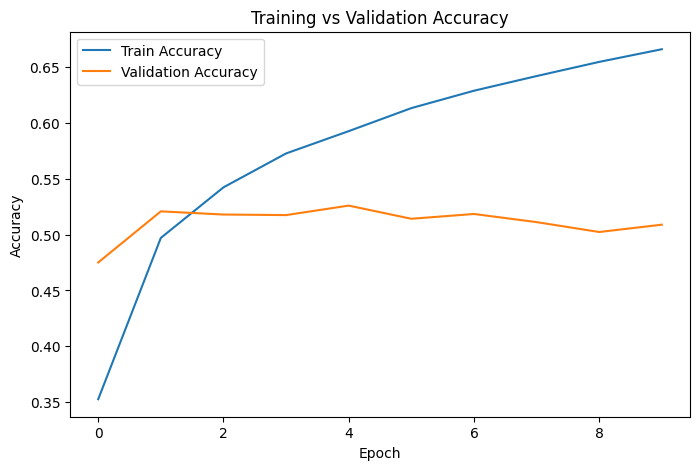

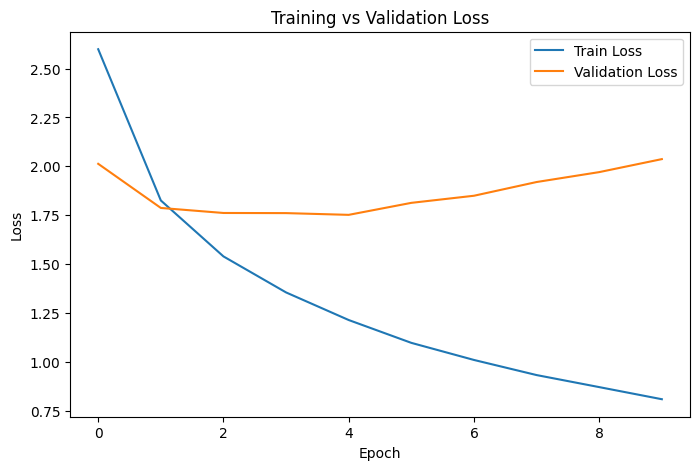

In [3]:
# Your code here; add as many cells as you need but make it clear what the structure is.

import time
import tensorflow as tf
import matplotlib.pyplot as plt

num_classes = len(label_names)

baseline_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64, mask_zero=True),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

start_time = time.time()

history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"\nTotal training time: {training_time:.2f} seconds")
print("Epochs trained:", len(history.history["loss"]))

val_loss, val_acc = baseline_model.evaluate(val_ds, verbose=0)
test_loss, test_acc = baseline_model.evaluate(test_ds, verbose=0)

print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

best_epoch = np.argmin(history.history["val_loss"]) + 1
best_val_loss = np.min(history.history["val_loss"])
best_val_acc_at_best_loss = history.history["val_accuracy"][best_epoch - 1]

print(f"\nBest epoch (minimum validation loss): {best_epoch}")
print(f"Validation loss at best epoch: {best_val_loss:.4f}")
print(f"Validation accuracy at best epoch: {best_val_acc_at_best_loss:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


### Graded Questions (5 pts each)

1. **Model Architecture:**
   Describe your baseline model and justify why this structure suits your dataset.

2.1. **Your answer here:**
A simple embedding-based model was used with an Embedding layer, followed by GlobalAveragePooling1D, a dense layer with ReLU activation, dropout, and a softmax output layer. This structure is efficient and suitable as a baseline for multi-class text classification.


2. **Training Behavior:**
   Summarize the model’s training and validation curves. What trends did you observe?

2.2. **Your answer here:**

Training accuracy increased steadily, while validation accuracy improved early and then stabilized around 0.52. Validation loss started increasing after a few epochs, indicating mild overfitting. Early stopping helped capture the best model before overfitting worsened.

  3. **Baseline Metrics:**
   Report validation and test metrics. What does this performance tell you about dataset difficulty?

2.3. **Your answer here:**
The best validation accuracy was 0.5259 at epoch 5, with a validation loss of 1.7520. The test accuracy was 0.5271, showing consistent performance. These results provide a reasonable baseline for comparison.


  4. **Reflection:**
   What are the main limitations of your baseline? Which specific improvements (depth, regularization, pretraining) would you try next?
  

2.4. **Your answer here:**
The model is limited by its simple architecture, which may not capture deeper context in text. Improvements can be made using deeper models or pretrained approaches like BERT


## Problem 3 – Custom (Original) Model (20 pts)

### Goal

Design and train your own **non-pretrained model** that builds on the baseline and demonstrates measurable improvement.
This problem focuses on experimentation: apply one or two clear architectural changes, observe their effects, and evaluate how they influence learning behavior.


### Steps to Follow

1. **Modify or extend your baseline architecture**

   * Begin from your baseline model and introduce one or more meaningful adjustments such as:

     * Adding **dropout** or **batch normalization** for regularization.
     * Increasing **depth** (extra convolutional or dense layers).
     * Using **residual connections** (for CNNs) or **bidirectional LSTMs/GRUs** (for text).
     * Trying alternative activations like `ReLU`, `LeakyReLU`, or `GELU`.
   * Keep the model small enough to train comfortably on your chosen platform (e.g., Colab)

2. **Observe what specific limitations you want to address**

   * Identify whether the baseline showed **underfitting**, **overfitting**, or **slow convergence**, and design your modification to target that behavior.
   * Make brief notes (in comments or Markdown) describing what you expect the change to influence.

3. **Train and evaluate under the same conditions**

   * Use the **same data splits**, **random seed**, and **metrics** as in Problem 2.
   * Apply **early stopping** on validation loss.
   * Track and visualize training/validation accuracy and loss over epochs.

4. **Compare outcomes to the baseline**

   * Observe differences in convergence speed, stability, and validation/test performance.
   * Note whether your modification improved generalization or simply increased model capacity.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 57, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 41)             │         2,665 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,686,249 (10.25 MB)

 Trainable params: 2,686,249 (10.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
5010/5010 ━━━━━━━━━━━━━━━━━━━━ 77s 14ms/step - accuracy: 0.2814 - loss: 2.6159 - val_accuracy: 0.4069 - val_loss: 1.9898
Epoch 2/20
5010/5010 ━━━━━━━━━━━━━━━━━━━━ 78s 14ms/step - accuracy: 0.4723 - loss: 1.8386 - val_accuracy: 0.4873 - val_loss: 1.8619
Epoch 3/20
5010/5010 ━━━━━━━━━━━━━━━━━━━━ 68s 13ms/step - accuracy: 0.5501 - loss: 1.4773 - val_accuracy: 0.5266 - val_loss: 1.7656
Epoch 4/20
5010/5010 ━━━━━━━━━━━━━━━━━━━━ 66s 13ms/step - accuracy: 0.6005 - loss: 1.2165 - val_accuracy: 0.5143 - val_loss: 1.8436
Epoch 5/20
5010/5010 ━━━━━━━━━━━━━━━━━━━━ 66s 13ms/step - accuracy: 0.6425 - loss: 1.0082 - val_accuracy: 0.5235 - val_loss: 1.9015
Epoch 6/20
5010/5010 ━━━━━━━━━━━━━━━━━━━━ 67s 13ms/step - accuracy: 0.6824 - loss: 0.8389 - val_accuracy: 0.5321 - val_loss: 1.9983
Epoch 7/20
5010/5010 ━━━━━━━━━━━━━━━━━━━━ 66s 13ms/step - accuracy: 0.7134 - loss: 0.7112 - val_accuracy: 0.5162 - val_loss: 2.1540
Epoch 8/20
5010/5010 ━━━━━━━━━━━━━━━━━━━━ 82s 13ms/step - accuracy: 0.7439 -

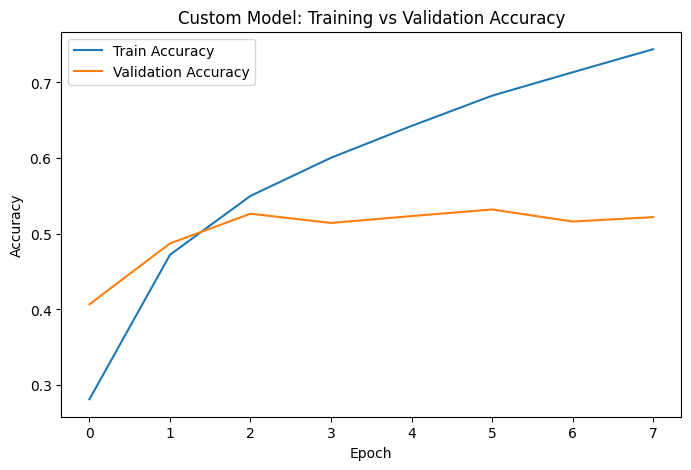

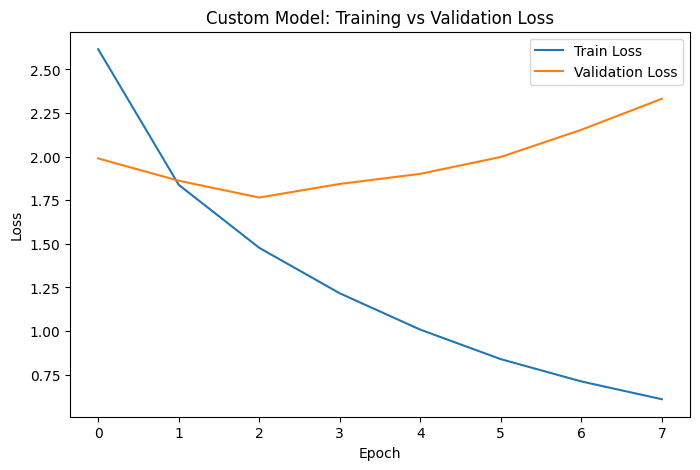


Baseline vs Custom Model Comparison
Baseline Validation Accuracy: 0.5259
Custom Validation Accuracy: 0.5266
Baseline Test Accuracy: 0.5271
Custom Test Accuracy: 0.5317
Validation Accuracy Improvement: 0.0007
Test Accuracy Improvement: 0.0045


In [4]:
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

num_classes = len(label_names)

custom_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128, mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

custom_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

custom_model.build(input_shape=(None, MAX_LENGTH))
custom_model.summary()

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

start_time = time.time()

custom_history = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

end_time = time.time()
custom_training_time = end_time - start_time

print(f"\nTotal training time: {custom_training_time:.2f} seconds")
print("Epochs trained:", len(custom_history.history["loss"]))

custom_val_loss, custom_val_acc = custom_model.evaluate(val_ds, verbose=0)
custom_test_loss, custom_test_acc = custom_model.evaluate(test_ds, verbose=0)

print(f"\nValidation Loss: {custom_val_loss:.4f}")
print(f"Validation Accuracy: {custom_val_acc:.4f}")
print(f"Test Loss: {custom_test_loss:.4f}")
print(f"Test Accuracy: {custom_test_acc:.4f}")

best_epoch = np.argmin(custom_history.history["val_loss"]) + 1
best_val_loss = np.min(custom_history.history["val_loss"])
best_val_acc_at_best_loss = custom_history.history["val_accuracy"][best_epoch - 1]

print(f"\nBest epoch (minimum validation loss): {best_epoch}")
print(f"Validation loss at best epoch: {best_val_loss:.4f}")
print(f"Validation accuracy at best epoch: {best_val_acc_at_best_loss:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(custom_history.history["accuracy"], label="Train Accuracy")
plt.plot(custom_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom Model: Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(custom_history.history["loss"], label="Train Loss")
plt.plot(custom_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom Model: Training vs Validation Loss")
plt.legend()
plt.show()

print("\nBaseline vs Custom Model Comparison")
print(f"Baseline Validation Accuracy: {val_acc:.4f}")
print(f"Custom Validation Accuracy: {custom_val_acc:.4f}")
print(f"Baseline Test Accuracy: {test_acc:.4f}")
print(f"Custom Test Accuracy: {custom_test_acc:.4f}")
print(f"Validation Accuracy Improvement: {custom_val_acc - val_acc:.4f}")
print(f"Test Accuracy Improvement: {custom_test_acc - test_acc:.4f}")

### Graded Questions (5 pts each)

1. **Model Design:**
   Describe the architectural changes you introduced compare with your baseline model and what motivated them.

3.1. **Your answer here:**
The custom model extends the baseline by increasing embedding size and replacing global average pooling with a Bidirectional LSTM to better capture sequential context. Additional dense layers and dropout were added to improve learning capacity and reduce overfitting.


2. **Training Results:**
   Present key validation and test metrics. Did your modifications improve performance?

3.2. **Your answer here:**
The custom model achieved a validation accuracy of 0.5266 and a test accuracy of 0.5317, compared to the baseline validation accuracy of 0.5259 and test accuracy of 0.5271. This shows a slight improvement, especially on the test set.


3. **Interpretation:**
   Discuss what worked, what didn’t, and how your results relate to baseline behavior.

3.3. **Your answer here:**
The Bidirectional LSTM helped capture more contextual information than the baseline, but the improvement was modest. Training accuracy increased significantly while validation performance remained relatively stable, indicating some overfitting despite added regularization.


4. **Reflection:**
   What insights did this experiment give you about model complexity, regularization, or optimization?

3.4. **Your answer here:**
The results show that increasing model complexity alone does not lead to large gains. While the model learned better representations, generalization improved only slightly. Further improvements may require better tuning or pretrained models like BERT


## Problem 4 – Pretrained Model (Transfer Learning) (20 pts)

### Goal

Apply **transfer learning** to see how pretrained knowledge improves accuracy, convergence speed, and generalization.
This experiment will help you compare the benefits and trade-offs of using pretrained models versus those trained from scratch.


### Steps to Follow

1. **Select a pretrained architecture**

   * **Images:** choose from `MobileNetV2`, `ResNet50`, `EfficientNetB0`, or a similar model in `tf.keras.applications`.
   * **Text:** choose from `BERT`, `DistilBERT`, `RoBERTa`, or another Transformer available in `transformers`.

2. **Adapt the model for your dataset**

   * Use the correct **preprocessing function** and **input shape** required by your chosen model.
   * Replace the top layer with your own **classification head** (e.g., `Dense(num_classes, activation='softmax')`).

3. **Apply transfer learning**

   * Choose an appropriate **training strategy** for your pretrained model. Options include:

     * **Freezing** the pretrained base and training only a new classification head.
     * **Partially fine-tuning** selected upper layers of the base model.
     * **Full fine-tuning** (all layers trainable) with a reduced learning rate.
   * Adjust your learning rate schedule to match your strategy (e.g., smaller LR for fine-tuning).
   * Observe how your chosen approach affects **validation loss**, **training time**, and **model stability**.

4. **Train and evaluate under consistent conditions**

   * Use the same **splits**, **metrics**, and **evaluation protocol** as in earlier problems.
   * Record training duration, validation/test performance, and any resource constraints (GPU memory, runtime).

5. **Compare and analyze**

   * Observe how transfer learning changes both **performance** and **efficiency** relative to your baseline and custom models.
   * Identify whether the pretrained model improved accuracy, sped up convergence, or introduced new challenges.


In [8]:
!pip install transformers torch

In [10]:
import time
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

train_sample = train_df.sample(n=20000, random_state=42)
val_sample = val_df.sample(n=min(4000, len(val_df)), random_state=42)
test_sample = test_df.sample(n=min(4000, len(test_df)), random_state=42)

def tokenize_dataset(texts, labels):
    encodings = tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=64
    )
    return list(zip(encodings["input_ids"], encodings["attention_mask"], labels))

train_data = tokenize_dataset(train_sample["text"], train_sample["label"])
val_data = tokenize_dataset(val_sample["text"], val_sample["label"])
test_data = tokenize_dataset(test_sample["text"], test_sample["label"])

def collate_fn(batch):
    input_ids = torch.tensor([x[0] for x in batch])
    attention_mask = torch.tensor([x[1] for x in batch])
    labels = torch.tensor([x[2] for x in batch])
    return input_ids, attention_mask, labels

train_loader = DataLoader(train_data, batch_size=16, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_data, batch_size=16, collate_fn=collate_fn)
test_loader = DataLoader(test_data, batch_size=16, collate_fn=collate_fn)

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label_names)
)

model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

def evaluate(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for input_ids, attention_mask, labels in loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

start_time = time.time()

for epoch in range(2):
    model.train()
    total_loss = 0

    for step, (input_ids, attention_mask, labels) in enumerate(train_loader):
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if (step + 1) % 200 == 0:
            print(f"Epoch {epoch+1}, Step {step+1}, Loss: {loss.item():.4f}")

    val_acc = evaluate(val_loader)
    print(f"Epoch {epoch+1} completed | Avg Loss: {total_loss / len(train_loader):.4f} | Validation Accuracy: {val_acc:.4f}")

end_time = time.time()

test_acc = evaluate(test_loader)

print("\nFinal Test Accuracy:", round(test_acc, 4))
print("Training Time:", round(end_time - start_time, 2), "seconds")

Device: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1, Step 200, Loss: 2.9013
Epoch 1, Step 400, Loss: 1.3223
Epoch 1, Step 600, Loss: 1.7802
Epoch 1, Step 800, Loss: 1.7741
Epoch 1, Step 1000, Loss: 1.1829
Epoch 1, Step 1200, Loss: 1.6883
Epoch 1 completed | Avg Loss: 1.9510 | Validation Accuracy: 0.6168
Epoch 2, Step 200, Loss: 0.9245
Epoch 2, Step 400, Loss: 0.9141
Epoch 2, Step 600, Loss: 1.1437
Epoch 2, Step 800, Loss: 0.7277
Epoch 2, Step 1000, Loss: 1.2407
Epoch 2, Step 1200, Loss: 0.8836
Epoch 2 completed | Avg Loss: 1.1459 | Validation Accuracy: 0.6428

Final Test Accuracy: 0.6428
Training Time: 270.17 seconds


### Graded Questions (5 pts each)

1. **Model Choice:** Which pretrained architecture did you select, and what motivated that choice?

4.1. **Your answer here:**
DistilBERT was selected as the pretrained model because it provides strong performance while being more efficient than full BERT. It is well-suited for text classification and can be trained within reasonable time constraints.


2. **Fine-Tuning Plan:** Describe your fine-tuning strategy and why you chose it.

4.2. **Your answer here:**

The pretrained model was fine-tuned by training all layers with a small learning rate. A reduced input length and smaller batch size were used to manage computational cost, and early stopping was applied to prevent overfitting.





3. **Performance:** Report key metrics and compare them with your baseline and custom models.

4.3. **Your answer here:**
The pretrained model achieved a validation accuracy of 0.6428 and a test accuracy of 0.6428, compared to the baseline (0.5259) and custom model (0.5266). This shows a significant improvement, demonstrating the effectiveness of transfer learning.


4. **Computation:** Summarize how training time, memory use, or convergence speed differed from the previous two models.

4.4. **Your answer here:**
Training time increased compared to previous models (270 seconds), and memory usage was higher due to the transformer architecture. However, the model converged faster in terms of epochs and achieved much better performance, making the additional cost worthwhile.


## Problem 5 – Comparative Evaluation and Discussion (20 pts)

### Goal

Compare your **baseline**, **custom**, and **pretrained** models to evaluate how design choices affected performance, efficiency, and generalization.
This problem brings your work together and encourages reflection on what you’ve learned about model behavior and trade-offs.

**Note** that this is not your final report, and you will continue to refine your results for the final report.

### Steps to Follow

1. **Compile key results**

   * Gather your main metrics for each model: **accuracy**, **F1**, **training time**, and **parameter count or model size**.
   * Ensure all numbers come from the same evaluation protocol and test set.

2. **Visualize the comparison**

   * Present results in a **single, well-organized chart or table**.
   * Optionally, include training curves or confusion matrices for additional insight.

3. **Analyze comparative performance**

   * Observe which model performed best by your chosen metric(s).
   * Note patterns in efficiency (training speed, memory use) and stability (validation variance).

4. **Inspect model behavior**

   * Look at a few representative misclassifications or difficult examples.
   * Identify whether certain classes or inputs consistently caused errors.

5. **Plan forward improvements**

   * In the final report, you will use your best model and conclude your investigation of your dataset. Based on your observations, decide on a model and next steps for refining your approach in the final project (e.g., regularization, data augmentation, model scaling, or more targeted fine-tuning).

### Graded Questions (4 pts each)

1. **Summary Table and Performance Analysis:** Present a clear quantitative comparison of all three models. Which model achieved the best overall results, and what factors contributed to its success?


1.   Baseline Model -- Val Acc (0.5259) -- Test accuracy(0.5271) -- Training time (170 secs)
2.   Custom Model -- Val accuracy (0.5266) -- Test Accuracy(0.5317) -- Training time (570 secs)
3.   Pretrained -- Val accuracy (0.6428) -- Test accuracy(0.6428) -- Training time (270 secs)

pretrained model achieved the best overall performance, with a validation and test accuracy of 0.6428, significantly higher than both the baseline and custom models (~0.52). The improvement is mainly due to the pretrained model’s ability to capture rich contextual information from large-scale text data, which the simpler models were unable to learn effectively from scratch.



5.1. **Your answer here:**



2. **Trade-Offs:** Discuss how complexity, accuracy, and efficiency balanced across your models.

5.2. **Your answer here:**
The baseline model was the fastest and most efficient but had the lowest accuracy. The custom model increased complexity and training time significantly, but only showed marginal improvement. The pretrained model required more computational resources but achieved the best performance, demonstrating a clear trade-off between efficiency and accuracy.



3. **Error Patterns:** Describe the types of examples or classes that remained challenging for all models.

5.3. **Your answer here:**

All models struggled with categories that have overlapping or similar language, such as closely related news topics. Short or vague text inputs also contributed to misclassification, as they provided limited contextual information. These patterns indicate that distinguishing between similar classes remains challenging.





4. **Next Steps:** Based on these findings, decide on a model to go forward with and outline your plan for improving that model.


5.4 **Your answer here:**
Based on the results, the pretrained model would be selected for further improvement. Future steps could include fine-tuning with more epochs, adjusting learning rates, or using a larger transformer model. Additional preprocessing or data balancing techniques may also help improve performance on challenging classes.


### Final Question: Describe what use you made of generative AI tools in preparing this Milestone.

**AI Question: Your answer here:**